In [ ]:
from obspy import UTCDateTime, read_inventory, read
from obspy.clients.fdsn.mass_downloader import RectangularDomain, Restrictions, MassDownloader
from obspy.clients.fdsn import Client
import numpy as np
import os, shutil
import warnings
import os
import glob
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

for i in range(25, 32):

    STARTTIME   = UTCDateTime("2025-12-"+str(i)+ " 09:00:00")
    DURATION    = 1.5 * 60*60 # [seconds]
    NETWORK     = "*"
    STATION     = "*"
    LOCATION    = "*"
    CHANNEL     = "HH*" # "HH*,BH*"
    LAT_MIN     =   32.5 #32.5
    LAT_MAX     =   35.5 #42.0
    LON_MIN     = -122.0 #125
    LON_MAX     = -114.1 #
    REJECT_GAPS = False
    SANITIZE    = True
    OUTPUT      = "VEL"
    PLOT        = False
    MINIMUM_LEN = 0.95 # percent of duration
    DATA_MAIN = "./Dec"+str(i)+"Data/"

    def get_mseed_filename(network, station, location, channel, starttime, endtime):
        # note that TMP_DIR is defined in the next code block
        starttime = str(starttime)[:19].replace("-","").replace("T","").replace(":","")
        endtime = str(endtime)[:19].replace("-","").replace("T","").replace(":","")
        filename = TMP_DIR + "%s.%s.%s.%s.%s.mseed"%(network, station, channel, location, starttime)
        return(filename)

    def get_stationxml_filename(network, station, channels, starttime, endtime):
        # note that TMP_DIR is defined in the next code block
        filename = TMP_DIR + "%s.%s.xml"%(network, station)
        return(filename)

    # Box around California (includes Nevada)
    DOMAIN = RectangularDomain(minlatitude=LAT_MIN,  maxlatitude=LAT_MAX,
                            minlongitude=LON_MIN, maxlongitude=LON_MAX)

    RESTRICTIONS = Restrictions(starttime=STARTTIME,
                                endtime=STARTTIME + DURATION,
                                chunklength_in_sec=DURATION,
                                network=NETWORK,
                                station=STATION,
                                location=LOCATION,
                                channel=CHANNEL,
                                sanitize=SANITIZE,
                                reject_channels_with_gaps=REJECT_GAPS,
                                minimum_length=MINIMUM_LEN,
                                minimum_interstation_distance_in_m=100.0,
                                )

    # Create a temporary folder to store all data:
    TMP_DIR = DATA_MAIN + "temp/"
    try:
        os.mkdir(TMP_DIR)
    except:
        pass

    # Run mass download:
    client = Client()
    mdl = MassDownloader()
    mdl.download(DOMAIN, RESTRICTIONS, 
                mseed_storage=get_mseed_filename, 
                stationxml_storage=get_stationxml_filename)

    # Move files to preferred file structure:
    STATIONS = [x[:x.find(".", x.find(".")+1)] for x in os.listdir(TMP_DIR) if x.endswith(".xml")]

    print(STATIONS)

    for station in STATIONS:
        
        try:
            
            os.mkdir(DATA_MAIN + station.replace(".","_"))
            
        except:
            
            pass # if the station already has data, you may end up with multiple time-windows 
                # (I think it is a good idea to keep this so that if one time-window has issues you can always try the other)
            # continue # skip this station because you already have data for it 
            
        for filename in [x for x in os.listdir(TMP_DIR) if (station in x)]:
            shutil.move(TMP_DIR + filename, DATA_MAIN + station.replace(".","_") + "/" + filename)

    # Delete temporary folder:
    try:
        shutil.rmtree(TMP_DIR)
    except:
        pass

[2026-02-22 15:24:27,997] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 15:24:29,671] - obspy.clients.fdsn.mass_downloader - WARNING: Failed to initialize client 'IESDMC'.
[2026-02-22 15:24:29,674] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'USGS' as it does not have 'dataselect' and/or 'station' services.
[2026-02-22 15:24:30,092] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'ISC' as it does not have 'dataselect' and/or 'station' services.
[2026-02-22 15:24:30,135] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'EMSC' as it does not have 'dataselect' and/or 'station' services.
[2026-02-22 15:24:30,486] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'USP' as it does not have 'dataselect' an

['CI.PDE', 'CI.PDR', 'CI.BUE', 'CI.BAW', 'CI.BCH', 'CI.LCP', 'CI.SOL2', 'CI.LCG', 'CI.DLA', 'CI.MSJ', 'CI.JTH', 'CI.HLL', 'CI.DTP', 'CI.SUN', 'CI.FMP', 'CI.SWP', 'CI.ADO', 'CI.RHC2', 'CI.JVA', 'CI.MPP', 'CI.CHN', 'CI.SNR', 'CI.SMI', 'CI.SLM', 'CI.OSI', 'CI.GR2', 'CI.RHR', 'CI.RPV', 'CI.BAC', 'CI.SOC', 'CI.CHL', 'CI.SYN', 'YN.JORD', 'CI.SWS', 'CI.ARV', 'CI.GSC', 'CI.LMY', 'CI.ERR', 'AZ.SND', 'CI.GFF', 'CI.BTP', 'CI.BOM', 'CI.CHI', 'CI.CPO', 'CI.SVD', 'CI.CRG', 'CI.CFT', 'CI.IRM', 'CI.LOC', 'CI.PASC', 'CI.RSI', 'PB.B082', 'CI.PDU', 'CI.NBS', 'CI.RRX', 'CI.BAR', 'CI.SMM', 'CI.ELS2', 'CI.CRR', 'CI.CKP', 'CI.SLH', 'CI.SBC', 'AZ.LVA2', 'CI.WWF', 'CI.BLC', 'CI.LMH', 'AZ.SIO5', 'BC.RMX', 'CI.PER', 'CI.GFS', 'AZ.FRD', 'CI.PLM', 'CI.RKMO', 'CI.MOP', 'CI.CCK', 'CI.DGR', 'CI.TOR', 'CI.OLI', 'CI.VCS', 'CI.SRI', 'CI.ALP', 'CI.OCP', 'CI.DRE', 'CI.CTC', 'CI.ABL', 'BC.TKX', 'CI.SDR', 'BK.PABC', 'CI.PZA', 'CI.GMR', 'CI.GLA', 'GM.KCS01', 'CI.WTT2', 'CI.LRL', 'CI.RUN', 'CI.BFS', 'CI.SDG', 'CI.HIW', 'CI.DS

[2026-02-22 15:33:43,092] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 15:33:43,092] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 15:33:44,137] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'RESIFPH5' as it does not have 'dataselect' and/or 'station' services.
[2026-02-22 15:33:44,137] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'RESIFPH5' as it does not have 'dataselect' and/or 'station' services.
[2026-02-22 15:33:44,142] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'ISC' as 

['CI.PDE', 'CI.PDR', 'CI.BUE', 'CI.BAW', 'CI.BCH', 'CI.LCP', 'CI.SOL2', 'CI.LCG', 'CI.DLA', 'CI.MSJ', 'CI.JTH', 'CI.HLL', 'CI.DTP', 'CI.SUN', 'CI.FMP', 'CI.SWP', 'CI.ADO', 'CI.RHC2', 'CI.JVA', 'CI.CHN', 'CI.SNR', 'CI.SMI', 'CI.SLM', 'CI.OSI', 'CI.GR2', 'CI.RHR', 'CI.RPV', 'CI.BAC', 'CI.SOC', 'CI.CHL', 'CI.SYN', 'YN.JORD', 'CI.SWS', 'CI.ARV', 'CI.GSC', 'CI.LMY', 'CI.ERR', 'AZ.SND', 'CI.GFF', 'CI.BTP', 'CI.BOM', 'CI.CHI', 'CI.CPO', 'CI.SVD', 'CI.CFT', 'CI.IRM', 'CI.LOC', 'CI.PASC', 'CI.RSI', 'PB.B082', 'CI.PDU', 'CI.NBS', 'CI.RRX', 'CI.BAR', 'CI.SMM', 'CI.ELS2', 'CI.CRR', 'CI.CKP', 'CI.SLH', 'CI.SBC', 'AZ.LVA2', 'CI.WWF', 'CI.BLC', 'CI.LMH', 'AZ.SIO5', 'BC.RMX', 'CI.PER', 'CI.GFS', 'AZ.FRD', 'CI.PLM', 'CI.RKMO', 'CI.MOP', 'CI.CCK', 'CI.DGR', 'CI.TOR', 'CI.OLI', 'CI.VCS', 'CI.SRI', 'CI.ALP', 'CI.OCP', 'CI.DRE', 'CI.CTC', 'CI.ABL', 'BC.TKX', 'CI.SDR', 'BK.PABC', 'CI.PZA', 'CI.GMR', 'CI.GLA', 'GM.KCS01', 'CI.WTT2', 'CI.LRL', 'CI.RUN', 'CI.BFS', 'CI.SDG', 'CI.HIW', 'CI.DSC', 'CI.HEC', 'CI.CT

[2026-02-22 15:43:16,064] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 15:43:16,064] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 15:43:16,064] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 15:43:17,447] - obspy.clients.fdsn.mass_downloader - INFO: Cannot use client 'RESIFPH5' as it does not have 'datase

...

['CI.PDE', 'CI.PDR', 'CI.BUE', 'CI.BAW', 'CI.BCH', 'CI.LCP', 'CI.SOL2', 'CI.LCG', 'CI.DLA', 'CI.MSJ', 'CI.JTH', 'CI.HLL', 'CI.DTP', 'CI.SUN', 'CI.FMP', 'CI.SWP', 'CI.ADO', 'CI.RHC2', 'CI.JVA', 'CI.MPP', 'CI.CHN', 'CI.SNR', 'CI.SMI', 'CI.SLM', 'CI.OSI', 'CI.GR2', 'CI.RHR', 'CI.RPV', 'CI.BAC', 'CI.SOC', 'CI.CHL', 'CI.SYN', 'YN.JORD', 'CI.SWS', 'CI.ARV', 'CI.GSC', 'CI.LMY', 'CI.ERR', 'AZ.SND', 'CI.GFF', 'CI.BTP', 'CI.BOM', 'CI.CHI', 'CI.CPO', 'CI.SVD', 'CI.CRG', 'CI.CFT', 'CI.IRM', 'CI.LOC', 'CI.PASC', 'CI.RSI', 'PB.B082', 'CI.PDU', 'CI.NBS', 'CI.RRX', 'CI.BAR', 'CI.SMM', 'CI.ELS2', 'CI.CRR', 'CI.CKP', 'CI.SLH', 'CI.SBC', 'AZ.LVA2', 'CI.WWF', 'CI.BLC', 'CI.LMH', 'AZ.SIO5', 'BC.RMX', 'CI.PER', 'CI.GFS', 'AZ.FRD', 'CI.PLM', 'CI.RKMO', 'CI.MOP', 'CI.CCK', 'CI.DGR', 'CI.TOR', 'CI.OLI', 'CI.VCS', 'CI.SRI', 'CI.ALP', 'CI.OCP', 'CI.DRE', 'CI.CTC', 'CI.ABL', 'BC.TKX', 'CI.SDR', 'BK.PABC', 'CI.PZA', 'CI.GMR', 'CI.GLA', 'GM.KCS01', 'CI.WTT2', 'CI.LRL', 'CI.RUN', 'CI.BFS', 'CI.SDG', 'CI.HIW', 'CI.DS

[2026-02-22 16:15:37,454] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 16:15:37,454] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 16:15:37,454] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 16:15:37,454] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC

['CI.PDE', 'CI.PDR', 'CI.BUE', 'CI.BAW', 'CI.BCH', 'CI.LCP', 'CI.SOL2', 'CI.LCG', 'CI.DLA', 'CI.MSJ', 'CI.JTH', 'CI.HLL', 'CI.DTP', 'CI.SUN', 'CI.FMP', 'CI.SWP', 'CI.ADO', 'CI.RHC2', 'CI.JVA', 'CI.MPP', 'CI.CHN', 'CI.SNR', 'CI.SMI', 'CI.SLM', 'CI.OSI', 'CI.GR2', 'CI.RHR', 'CI.RPV', 'CI.BAC', 'CI.SOC', 'CI.CHL', 'CI.SYN', 'YN.JORD', 'CI.SWS', 'CI.ARV', 'CI.GSC', 'CI.LMY', 'CI.ERR', 'AZ.SND', 'CI.GFF', 'CI.BTP', 'CI.BOM', 'CI.CHI', 'CI.CPO', 'CI.SVD', 'CI.CRG', 'CI.CFT', 'CI.IRM', 'CI.LOC', 'CI.PASC', 'CI.RSI', 'PB.B082', 'CI.PDU', 'CI.NBS', 'CI.RRX', 'CI.BAR', 'CI.SMM', 'CI.ELS2', 'CI.CRR', 'CI.CKP', 'CI.SLH', 'CI.SBC', 'AZ.LVA2', 'CI.WWF', 'CI.BLC', 'CI.LMH', 'AZ.SIO5', 'CI.PER', 'CI.GFS', 'AZ.FRD', 'CI.PLM', 'CI.RKMO', 'CI.MOP', 'CI.CCK', 'CI.DGR', 'CI.TOR', 'CI.OLI', 'CI.VCS', 'CI.SRI', 'CI.ALP', 'CI.OCP', 'CI.DRE', 'CI.CTC', 'CI.ABL', 'BC.TKX', 'CI.SDR', 'BK.PABC', 'CI.PZA', 'CI.GMR', 'CI.GLA', 'GM.KCS01', 'CI.WTT2', 'CI.LRL', 'CI.RUN', 'CI.BFS', 'CI.SDG', 'CI.HIW', 'CI.DSC', 'CI.HE

[2026-02-22 16:25:34,266] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 16:25:34,266] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 16:25:34,266] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC, ETH, GEOFON, GEONET, GFZ, ICGC, IESDMC, INGV, IPGP, ISC, KNMI, KOERI, LMU, NCEDC, NIEP, NOA, RESIF, RESIFPH5, SCEDC, TEXNET, UIB-NORSAR, USGS, USP, ORFEUS, IRIS.
[2026-02-22 16:25:34,266] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for AUSPASS, BGR, EIDA, EMSC

['CI.PDE', 'CI.PDR', 'CI.BUE', 'CI.BAW', 'CI.BCH', 'CI.LCP', 'CI.SOL2', 'CI.LCG', 'CI.DLA', 'CI.MSJ', 'CI.JTH', 'CI.HLL', 'CI.DTP', 'CI.SUN', 'CI.FMP', 'CI.SWP', 'CI.ADO', 'CI.RHC2', 'CI.JVA', 'CI.MPP', 'CI.CHN', 'CI.SNR', 'CI.SMI', 'CI.SLM', 'CI.OSI', 'CI.GR2', 'CI.RHR', 'CI.RPV', 'CI.BAC', 'CI.SOC', 'CI.CHL', 'CI.SYN', 'YN.JORD', 'CI.SWS', 'CI.ARV', 'CI.GSC', 'CI.LMY', 'CI.ERR', 'AZ.SND', 'CI.GFF', 'CI.BTP', 'CI.BOM', 'CI.CHI', 'CI.CPO', 'CI.SVD', 'CI.CRG', 'CI.CFT', 'CI.IRM', 'CI.LOC', 'CI.PASC', 'CI.RSI', 'PB.B082', 'CI.PDU', 'CI.NBS', 'CI.RRX', 'CI.BAR', 'CI.SMM', 'CI.ELS2', 'CI.CRR', 'CI.CKP', 'CI.SLH', 'CI.SBC', 'AZ.LVA2', 'CI.WWF', 'CI.BLC', 'CI.LMH', 'AZ.SIO5', 'CI.PER', 'CI.GFS', 'AZ.FRD', 'CI.PLM', 'CI.RKMO', 'CI.MOP', 'CI.CCK', 'CI.DGR', 'CI.TOR', 'CI.OLI', 'CI.VCS', 'CI.SRI', 'CI.ALP', 'CI.OCP', 'CI.DRE', 'CI.CTC', 'CI.ABL', 'BC.TKX', 'CI.SDR', 'BK.PABC', 'CI.PZA', 'CI.GMR', 'CI.GLA', 'GM.KCS01', 'CI.WTT2', 'CI.LRL', 'CI.RUN', 'CI.BFS', 'CI.SDG', 'CI.HIW', 'CI.DSC', 'CI.HE

Found 591 unique stations from StationXML.


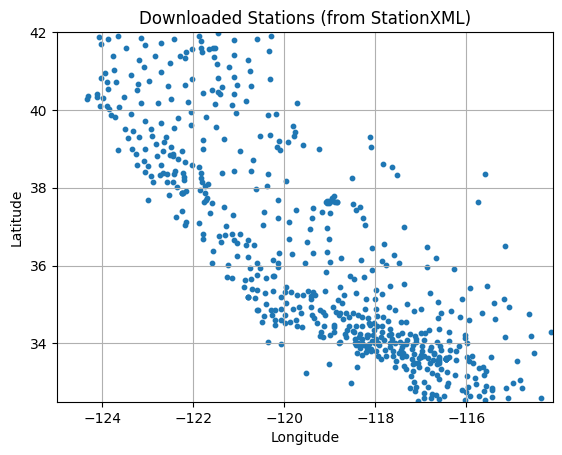

In [ ]:
DATA_MAIN = "./Dec25Data/"

# 1) find all StationXML files anywhere under DATA_MAIN (after you moved them)
xml_files = glob.glob(os.path.join(DATA_MAIN, "**", "*.xml"), recursive=True)

stations = {}

for xf in xml_files:
    try:
        inv = read_inventory(xf)
    except Exception as e:
        continue

    for net in inv:
        for sta in net.stations:
            key = f"{net.code}.{sta.code}"
            lat = getattr(sta, "latitude", None)
            lon = getattr(sta, "longitude", None)
            if lat is None or lon is None:
                continue
            stations[key] = (float(lat), float(lon))

print(f"Found {len(stations)} unique stations from StationXML.")

lats = np.array([v[0] for v in stations.values()])
lons = np.array([v[1] for v in stations.values()])

plt.figure()
plt.scatter(lons, lats, s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Downloaded Stations (from StationXML)")

plt.xlim(-125.0, -114.1)
plt.ylim(32.5, 42.0)

plt.grid(True)
plt.show()
